### 1. Tạo và tương tác với quantum circuit

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_vector
import matplotlib.pyplot as plt
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result().get_counts()
print(result)


### Lỗi trên có nghĩa gì?

In [80]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_vector
import matplotlib.pyplot as plt
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
# qc.measure([0, 1, 2], [0, 1, 2])
# simulator = AerSimulator(method = 'statevector')
# result = simulator.run(qc, shots=1000).result().get_counts()
# print(result)

/opt/anaconda3/envs/quantum_env/lib/python3.10/site-packages/numpy/ma/core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
/opt/anaconda3/envs/quantum_env/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/opt/anaconda3/envs/quantum_env/lib/python3.10/site-packages/matplotlib/transforms.py:1854: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


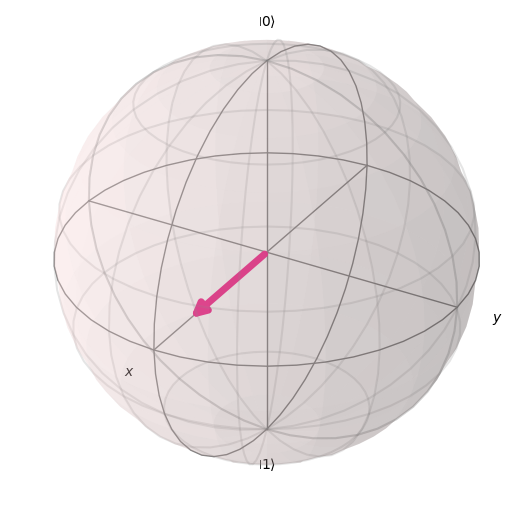

In [84]:
from qiskit import quantum_info as qi
plot_bloch_vector((qi.Statevector.from_instruction(qc)))

In [3]:
qc.draw()

┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2

### Tạo Hamiltonian $H=Z\otimes Z+1/2X\otimes I$

$$
I =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
,
X =
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
,
Y =
\begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}
,
Z =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

In [74]:
from qiskit.quantum_info import SparsePauliOp
hamiltonian = SparsePauliOp.from_list([
    ("ZZ", 1.0), 
    ("XI", 0.5)
])

print(hamiltonian.to_matrix())

[[ 1. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [ 0. +0.j -1. +0.j  0. +0.j  0.5+0.j]
 [ 0.5+0.j  0. +0.j -1. +0.j  0. +0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  1. +0.j]]


In [73]:
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import Estimator
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

op_q0 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
op_q1 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
op_q2 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])

projector_000 = op_q2.tensor(op_q1).tensor(op_q0)

estimator = Estimator()
job = estimator.run(qc, projector_000, shots=1000)
result = job.result()

print(result.values[0])

0.502


### Parameterized quantum circuit

In [8]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
thetas = ParameterVector('theta', 3)
qc = QuantumCircuit(3)
qc.rx(thetas[0], 0)
qc.ry(thetas[1], 1)
qc.crz(thetas[2], 2, 0)
qc.draw()

┌──────────────┐┌──────────────┐
q_0: ┤ Rx(theta[0]) ├┤ Rz(theta[2]) ├
     ├──────────────┤└──────┬───────┘
q_1: ┤ Ry(theta[1]) ├───────┼────────
     └──────────────┘       │        
q_2: ───────────────────────■────────

In [10]:
real_thetas = [0.5, 1.0, 1.5]
qc_assigned = qc.assign_parameters(real_thetas)
qc_assigned.draw()

┌─────────┐┌─────────┐
q_0: ┤ Rx(0.5) ├┤ Rz(1.5) ├
     └┬───────┬┘└────┬────┘
q_1: ─┤ Ry(1) ├──────┼─────
      └───────┘      │     
q_2: ────────────────■─────

### Chuẩn bị trạng thái ban đầu 
$|\psi\rangle = U|00...0\rangle$

In [21]:
from qiskit import QuantumCircuit
import numpy as np
qc = QuantumCircuit(3, 3)
qc.initialize(np.sqrt(1/3)*np.array([1, 0, 1, 0, 0, 0, 0, 1]), [0,1,2])
qc.draw()

┌────────────────────────────────────────────────┐
q_0: ┤0                                               ├
     │                                                │
q_1: ┤1 Initialize(0.57735,0,0.57735,0,0,0,0,0.57735) ├
     │                                                │
q_2: ┤2                                               ├
     └────────────────────────────────────────────────┘
c: 3/══════════════════════════════════════════════════

In [25]:
from qiskit import transpile
qc_transpiled = transpile(qc, basis_gates=['u3', 'cx'])
qc_transpiled.draw()

global phase: π/2
          ┌─────────────────┐                     ┌───┐┌───────────────────┐»
q_0: ─|0>─┤ U3(3π/4,0,-π/2) ├─────────────────────┤ X ├┤ U3(π/2,-3π/4,π/2) ├»
          ├─────────────────┴┐┌───┐┌─────────────┐└─┬─┘└───────────────────┘»
q_1: ─|0>─┤ U3(π/4,-2π,-π/2) ├┤ X ├┤ U3(π/4,0,0) ├──■───────────────────────»
          └┬───────────────┬─┘└─┬─┘└─────────────┘                          »
q_2: ─|0>──┤ U3(1.231,0,0) ├────■───────────────────────────────────────────»
           └───────────────┘                                                »
c: 3/═══════════════════════════════════════════════════════════════════════»
                                                                            »
«     ┌───┐┌───────────────────┐┌───┐┌───────────────┐
«q_0: ┤ X ├┤ U3(π/2,-π/2,3π/4) ├┤ X ├┤ U3(π/4,-π,-π) ├
«     └─┬─┘└───────────────────┘└─┬─┘└───────────────┘
«q_1: ──┼─────────────────────────■───────────────────
«       │                                             
«q_2: ──■─────────────────────────────────────────────
«                                                     
«c: 3/════════════════════════════════════════════════
«

### Tự tạo cổng riêng và sử dụng

In [26]:
from qiskit import QuantumCircuit
from qiskit.circuit import Gate
my_gate_1 = QuantumCircuit(2, name="MyGate1")
my_gate_1.x(0)
my_gate_1.h(1)
my_gate_1.cz(0, 1)
my_gate_1 = my_gate_1.to_gate()

my_gate_2 = QuantumCircuit(1, name="MyGate2")
my_gate_2.unitary([[0, 1], [1, 0]], 0)
my_gate_2 = my_gate_2.to_gate()

In [28]:
qc = QuantumCircuit(3)
qc.append(my_gate_1, [0, 1])
qc.append(my_gate_1, [1, 2])
qc.append(my_gate_2, [2])
print(qc.draw())

     ┌──────────┐                       
q_0: ┤0         ├───────────────────────
     │  MyGate1 │┌──────────┐           
q_1: ┤1         ├┤0         ├───────────
     └──────────┘│  MyGate1 │┌─────────┐
q_2: ────────────┤1         ├┤ MyGate2 ├
                 └──────────┘└─────────┘


### Tạo một "ansatz"

In [48]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def he_ansatz(num_qubits, num_layers):
    qc = QuantumCircuit(num_qubits)
    params = ParameterVector("thetas", length=num_qubits * (num_layers + 1))
    param_idx = 0
    
    for r in range(num_layers):
        for i in range(num_qubits):
            qc.ry(params[param_idx], i)
            param_idx += 1
        
        qc.barrier()
        
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)
        
        qc.barrier()
    
    for i in range(num_qubits):
        qc.ry(params[param_idx], i)
        param_idx += 1
    
    return qc

he_ansatz_circuit = he_ansatz(4, 2)
print(he_ansatz_circuit.draw())


     ┌───────────────┐ ░                 ░ ┌───────────────┐ ░                »
q_0: ┤ Ry(thetas[0]) ├─░───■─────────────░─┤ Ry(thetas[4]) ├─░───■────────────»
     ├───────────────┤ ░ ┌─┴─┐           ░ ├───────────────┤ ░ ┌─┴─┐          »
q_1: ┤ Ry(thetas[1]) ├─░─┤ X ├──■────────░─┤ Ry(thetas[5]) ├─░─┤ X ├──■───────»
     ├───────────────┤ ░ └───┘┌─┴─┐      ░ ├───────────────┤ ░ └───┘┌─┴─┐     »
q_2: ┤ Ry(thetas[2]) ├─░──────┤ X ├──■───░─┤ Ry(thetas[6]) ├─░──────┤ X ├──■──»
     ├───────────────┤ ░      └───┘┌─┴─┐ ░ ├───────────────┤ ░      └───┘┌─┴─┐»
q_3: ┤ Ry(thetas[3]) ├─░───────────┤ X ├─░─┤ Ry(thetas[7]) ├─░───────────┤ X ├»
     └───────────────┘ ░           └───┘ ░ └───────────────┘ ░           └───┘»
«      ░ ┌───────────────┐ 
«q_0: ─░─┤ Ry(thetas[8]) ├─
«      ░ ├───────────────┤ 
«q_1: ─░─┤ Ry(thetas[9]) ├─
«      ░ ├───────────────┴┐
«q_2: ─░─┤ Ry(thetas[10]) ├
«      ░ ├────────────────┤
«q_3: ─░─┤ Ry(thetas[11]) ├
«      ░ └────────────────┘


In [32]:
from qiskit.quantum_info import SparsePauliOp

h2_hamiltonian = SparsePauliOp.from_list([
    ("II", -1.0523732451573143),
    ("IZ", 0.39793742484318045),
    ("ZI", -0.39793742484318045),
    ("ZZ", -0.01128010425623538),
    ("XX", 0.18093119978423156)
])

print(h2_hamiltonian.to_matrix())


[[-1.06365335+0.j  0.        +0.j  0.        +0.j  0.1809312 +0.j]
 [ 0.        +0.j -1.83696799+0.j  0.1809312 +0.j  0.        +0.j]
 [ 0.        +0.j  0.1809312 +0.j -0.24521829+0.j  0.        +0.j]
 [ 0.1809312 +0.j  0.        +0.j  0.        +0.j -1.06365335+0.j]]


### Tính "gradient"

In [52]:
import numpy as np
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import gradients
from qiskit_algorithms.gradients import FiniteDiffEstimatorGradient, ParamShiftEstimatorGradient
from qiskit.primitives import StatevectorEstimator


ansatz = he_ansatz(2, 1)
thetas = np.random.uniform(0, 2*np.pi, len(ansatz.parameters))
hamiltonian = SparsePauliOp.from_list([("ZZ", 1.0)])

def gradient_finite_diff(ansatz, hamiltonian, thetas, epsilon):
    estimator = StatevectorEstimator()
    gradient_calculator = FiniteDiffEstimatorGradient(
        estimator, 
        epsilon = epsilon
    )


    result = gradient_calculator.run(
        circuits=[ansatz], 
        observables=[hamiltonian],
        parameter_values=[thetas]
    ).result()

    gradients = result.gradients[0]
    return gradients

def gradient_param_shift(ansatz, hamiltonian, thetas):
    estimator = StatevectorEstimator()
    gradient_calculator = ParamShiftEstimatorGradient(estimator)

    result = gradient_calculator.run(
        circuits=[ansatz], 
        observables=[hamiltonian],
        parameter_values=[thetas]
    ).result()

    gradients = result.gradients[0]
    return gradients

gradient_value_finite = gradient_finite_diff(ansatz, hamiltonian, thetas, epsilon=0.01)
gradient_value_param_shift = gradient_param_shift(ansatz, hamiltonian, thetas)
print(f"Tham số đầu vào: {thetas}")
print(f"Gradients (Finite Difference): {gradient_value_finite}")
print(f"Gradients (Parameter Shift): {gradient_value_param_shift}")


Tham số đầu vào: [1.88123111 5.5218153  0.79331558 6.13666201]
Gradients (Finite Difference): [ 0.09906448  0.45612428 -0.62981665  0.59922038]
Gradients (Parameter Shift): [ 0.09906613  0.45613189 -0.62982715  0.59923037]
